In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[ -6.02259735,   6.77749056],
       [ -6.89741035,  -8.91705909],
       [ -6.97277148, -10.52541848],
       ...,
       [ -6.4879867 ,   6.60198264],
       [ -5.95492254,   9.05482383],
       [ -7.17662394,   8.12433981]], shape=(1000, 2))

In [4]:
y

array([0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 1, 2, 1, 0, 2, 2, 0, 1, 1, 2, 1,
       0, 2, 2, 1, 1, 2, 1, 0, 2, 2, 1, 2, 1, 1, 1, 2, 2, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 2, 2, 1, 0, 2, 2, 2, 0, 2, 1, 1, 0, 1, 0, 2, 2, 2,
       2, 0, 2, 1, 0, 2, 1, 0, 2, 0, 0, 2, 1, 0, 0, 0, 2, 1, 2, 0, 1, 1,
       0, 1, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0, 2, 1, 0, 2, 2, 2, 1, 2, 2, 1,
       0, 0, 2, 2, 1, 0, 1, 0, 2, 2, 0, 0, 2, 2, 1, 0, 2, 2, 2, 2, 1, 0,
       0, 0, 1, 2, 1, 0, 1, 2, 2, 1, 1, 0, 1, 1, 1, 1, 0, 2, 0, 1, 1, 2,
       0, 0, 0, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 2,
       0, 0, 2, 0, 0, 1, 2, 0, 0, 2, 2, 1, 1, 2, 2, 0, 1, 1, 2, 2, 1, 2,
       2, 0, 0, 0, 2, 2, 0, 1, 0, 2, 2, 1, 2, 2, 1, 1, 1, 2, 2, 0, 1, 2,
       2, 2, 1, 1, 0, 0, 2, 2, 2, 0, 2, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 2, 0, 0, 0, 1, 1, 1, 2, 0, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 2, 2,
       2, 1, 0, 2, 1, 2, 0, 1, 0, 0, 2, 2, 0, 2, 2,

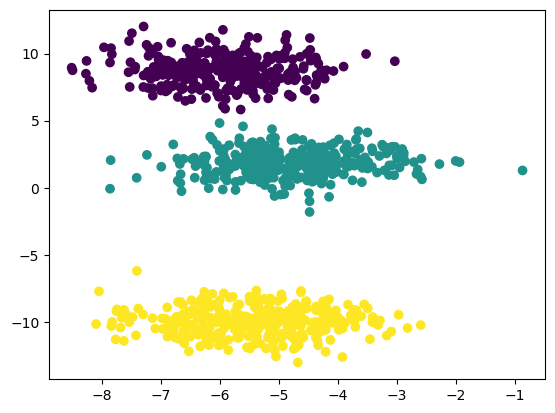

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
## standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [8]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans

In [10]:
##Elbow method To select K value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

In [ ]:
wcss # k incr then wcss val decr

[1499.9999999999995,
 864.8554238208308,
 493.64227789851736,
 378.8083159298323,
 265.82913605939996,
 215.3044737147393,
 177.69711814219852,
 143.8785077197536,
 129.33941343943044,
 102.10505634395119]

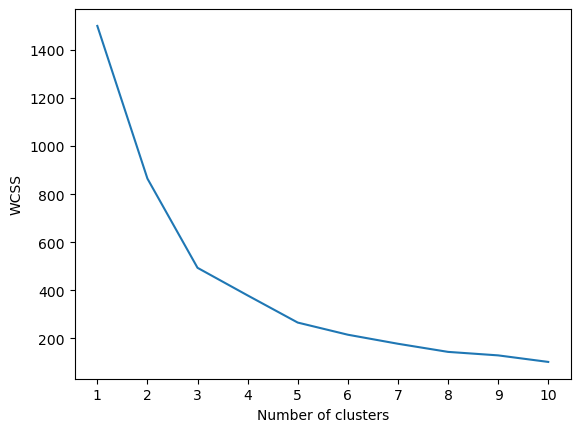

In [13]:
#plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [15]:
kmeans.fit_predict(X_train_scaled)

e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([2, 0, 1, 2, 1, 2, 2, 0, 1, 1, 2, 2, 1, 2, 2, 0, 0, 2, 1, 1, 1, 2,
       0, 0, 2, 1, 0, 1, 1, 2, 1, 2, 0, 0, 2, 1, 1, 1, 2, 1, 1, 0, 1, 1,
       2, 0, 1, 1, 1, 1, 2, 1, 0, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1,
       2, 1, 2, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 2,
       1, 2, 0, 0, 0, 1, 1, 0, 2, 0, 1, 0, 0, 0, 1, 1, 2, 1, 2, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 0, 0, 1, 2, 2, 2, 1, 1, 0, 1, 1, 1, 0, 0,
       2, 1, 2, 0, 0, 1, 2, 2, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1, 2, 1, 2, 2,
       2, 1, 1, 1, 1, 2, 0, 2, 0, 0, 2, 2, 1, 1, 2, 1, 0, 2, 1, 1, 1, 2,
       1, 1, 1, 2, 2, 2, 1, 1, 0, 2, 2, 0, 2, 0, 1, 0, 1, 1, 0, 1, 2, 0,
       0, 2, 2, 1, 0, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 0, 0, 2, 1, 1, 1, 2,
       0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 1, 2, 0, 2, 2, 1, 1, 0, 2, 2, 0, 1,
       0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2,
       1, 0, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 2, 0, 2, 1, 0,
       2, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 2, 0, 2, 0,

In [16]:
y_pred=kmeans.predict(X_test_scaled)

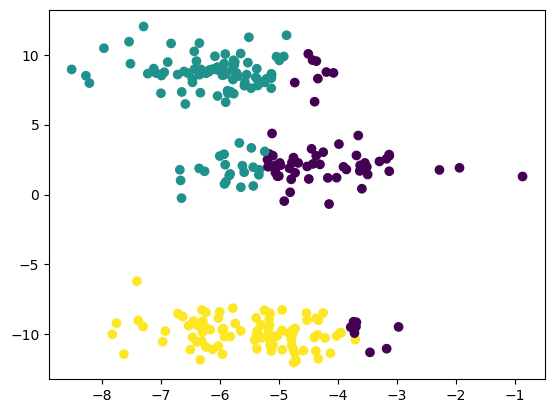

In [17]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [ ]:
#validating the k value
# kneelocator
#silhoutee scoring


In [19]:
!pip install kneed

In [21]:
from kneed import KneeLocator

In [23]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [24]:
kl.elbow

np.int64(3)

In [25]:
## silhoutee scoring 
from sklearn.metrics import silhouette_score


In [26]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

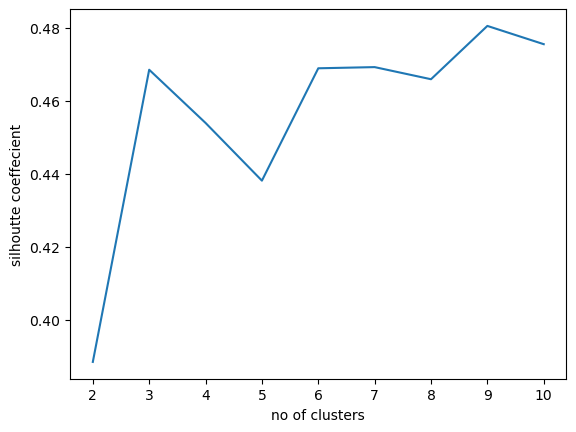

In [27]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("no of clusters")
plt.ylabel("silhoutte coeffecient")
plt.show()